# Data inspection: dicarlo.Rajalingham2018.public


The files are pulled directly from the DiCarlo lab's S3 bucket and hash-verified.

In [1]:
import hashlib
import os
import requests

CACHE_DIR = os.path.expanduser("~/.brainio_manual")
os.makedirs(CACHE_DIR, exist_ok=True)

# URLs and sha1 hashes copied from brainio_collection's own lookup.csv
FILES = {
    "assembly": (
        "https://s3.amazonaws.com/brainio.dicarlo/assy_dicarlo_Rajalingham2018_public.nc",
        "34c6a8b6f7c523589c1861e4123232e5f7c7df4c",
    ),
    "stimuli_csv": (
        "https://s3.amazonaws.com/brainio.dicarlo/image_dicarlo_objectome_public.csv",
        "47884e17106a3be471d6481279cab33889b80850",
    ),
    "stimuli_zip": (
        "https://s3.amazonaws.com/brainio.dicarlo/image_dicarlo_objectome_public.zip",
        "064f2955f98e63867755fee2e3ead8cddf6bfab8",
    ),
}

paths = {}
for name, (url, expected_sha1) in FILES.items():
    local_path = os.path.join(CACHE_DIR, os.path.basename(url))
    if not os.path.exists(local_path):
        response = requests.get(url, timeout=60)
        response.raise_for_status()
        payload = response.content
        assert hashlib.sha1(payload).hexdigest() == expected_sha1, f"download hash mismatch for {name}"
        with open(local_path, "wb") as stream:
            stream.write(payload)

    actual_sha1 = hashlib.sha1(open(local_path, "rb").read()).hexdigest()
    assert actual_sha1 == expected_sha1, f"sha1 mismatch for {name}"
    paths[name] = local_path
    print(f"{name}: fetched and verified OK")

assembly: fetched and verified OK
stimuli_csv: fetched and verified OK
stimuli_zip: fetched and verified OK


All three files downloaded and SHA-1-verified against brainio's own lookup table (confirmed it is a bit-for-bit the same files brain-score itself would fetch). Files downloaded:<br>
1. assembly - the raw behavioural data<br>
2. stimulus zip - set of image used as stimuli during behavioural trials<br>
3. stimulus CSV - image metadata (which category each image belongs to)


## 1. The behavioural dataset (assembly)

In [2]:
import xarray as xr
import pandas as pd

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 220)

assembly = xr.open_dataarray(paths["assembly"])
print("n trials:", len(assembly))
print("one row per trial?", assembly.dims == ("presentation",))

n trials: 585511
one row per trial? True


In [3]:
# Build a plain dataframe of everything, then check the columns mean what their names suggest.
df = pd.DataFrame({c: assembly.coords[c].values for c in assembly.coords})
df["values"] = assembly.values
print(df.shape)

from IPython.display import display
display(df.head(5))

print("dtypes:\n", df.dtypes)
print()
print("n unique image_id:", df["image_id"].nunique())
print("n unique WorkerID (subjects):", df["WorkerID"].nunique())
print("n unique AssignmentID:", df["AssignmentID"].nunique())
print("n unique sample_obj (categories?):", df["sample_obj"].nunique())
print("n unique dist_obj:", df["dist_obj"].nunique())
print()
print("sample_obj == truth always?", (df["sample_obj"] == df["truth"]).all())
print("choice in {sample_obj, dist_obj} always?",
      ((df["choice"] == df["sample_obj"]) | (df["choice"] == df["dist_obj"])).all())

(585511, 8)


,sample_obj,dist_obj,choice,image_id,WorkerID,AssignmentID,truth,values
0,MB28699,dromedary,MB28699,acaf817c42d2a46130e6ee67dad1b7d01f5276ab,AIW6ALUI8LBXV,2W9GYQ4J3NABXRMPS3FY2IT39ZKCPJ,MB28699,MB28699
1,22_acoustic_guitar,interior_details_130_2,22_acoustic_guitar,c6136cce2b429dad2a0d524051a3b34188bf4b85,A15NH461BKAYCX,2W33Q39Z0B6UK4DWH2MSXVRMW51LW3,22_acoustic_guitar,22_acoustic_guitar
2,MB27346,womens_shorts_01M,MB27346,8f7c403960a68cc3435e9c3585ed713c57a3ed4f,A15NH461BKAYCX,2W33Q39Z0B6UK4DWH2MSXVRMW51LW3,MB27346,MB27346
3,lo_poly_animal_BEAR_BLK,womens_shorts_01M,lo_poly_animal_BEAR_BLK,f8d98a46f773e850f1dc8066c16fca2f642e404e,A3MA2A9U1VMTRP,244F806UFBNFJBNXY3U99SW83W6F1T,lo_poly_animal_BEAR_BLK,lo_poly_animal_BEAR_BLK
4,MB30203,antique_furniture_item_18,MB30203,f95656b93edd8313b7b989e4c60da7b65c4335c9,A312ROTE0U1328,2GMXFCD45XCEK3KV0HBIR3TI5K5WY6,MB30203,MB30203


dtypes:
 sample_obj      object
dist_obj        object
choice          object
image_id        object
WorkerID        object
AssignmentID    object
truth           object
values          object
dtype: object

n unique image_id: 2160
n unique WorkerID (subjects): 1391
n unique AssignmentID: 8185
n unique sample_obj (categories?): 24
n unique dist_obj: 24

sample_obj == truth always? True


choice in {sample_obj, dist_obj} always? False


2,160 unique images and 24 categories confirmed.<br>
sample_obj (the target category) and truth (ground truth) are the same throughout the table as it should be the case.<br>
The recorded choice should match one of the two offered choices - target or distractor. In the next cell it was found that 2 out of 585,511 do not match.

In [4]:
# choice not always in {sample_obj, dist_obj} - look at the mismatches
mismatch = df[~((df["choice"] == df["sample_obj"]) | (df["choice"] == df["dist_obj"]))]
print("n mismatched rows:", len(mismatch), "out of", len(df))
mismatch[["sample_obj", "dist_obj", "choice", "truth"]]

n mismatched rows: 2 out of 585511


,sample_obj,dist_obj,choice,truth
115910,dromedary,lo_poly_animal_RHINO_2,womens_shorts_01M,dromedary
115916,womens_stockings_01M,dromedary,lo_poly_animal_RHINO_2,womens_stockings_01M


Only 2 rows out of 585,511 have a `choice` that matches neither the sample nor distractor object shown on that trial.<br>
These 2 rows are EXCLUDED in notebook 03, before selecting the test images and exporting the data.

## 2. The stimulus set: images, categories, tested/untested split

In [5]:
stim_df = pd.read_csv(paths["stimuli_csv"])
print("shape:", stim_df.shape)
print("columns:", list(stim_df.columns))
stim_df.head(10)

shape: (2160, 5)
columns: ['image_label', 'image_id', 'filename', 'id', 'image_sample_obj']


,image_label,image_id,filename,id,image_sample_obj
0,flarenut_spanner,0020cef91bd626e9fbbabd853494ee444e5c9ecb,0020cef91bd626e9fbbabd853494ee444e5c9ecb.png,133477,flarenut_spanner
1,dromedary,00a313fc5929bb79e49ead5de202a317eeafe659,00a313fc5929bb79e49ead5de202a317eeafe659.png,133478,dromedary
2,MB29874,00c6269c951f5ce5bf0a77c45c5e6fb3d2ec694e,00c6269c951f5ce5bf0a77c45c5e6fb3d2ec694e.png,133479,MB29874
3,MB29874,00e9fb160a10345d5a27850c946195724583514b,00e9fb160a10345d5a27850c946195724583514b.png,133480,MB29874
4,interior_details_130_2,0119aa4a7957d1db7f4e6803f00d3868eb8e028b,0119aa4a7957d1db7f4e6803f00d3868eb8e028b.png,133481,interior_details_130_2
5,zebra,0142a13bb38b90f6d4209470969b65d25908b12e,0142a13bb38b90f6d4209470969b65d25908b12e.png,133482,zebra
6,dromedary,015c5f3daa102400ffbd38b5e801d631146baff7,015c5f3daa102400ffbd38b5e801d631146baff7.png,133483,dromedary
7,lo_poly_animal_ELE_AS1,015dd19f8f1c1f10009b8ae2c4ab30e39055ac77,015dd19f8f1c1f10009b8ae2c4ab30e39055ac77.png,133484,lo_poly_animal_ELE_AS1
8,calc01,01a2f827c6d057f0821e1670a7f84efa36832733,01a2f827c6d057f0821e1670a7f84efa36832733.png,133485,calc01
9,antique_furniture_item_18,01a34e9d8aa8ae7ea73d54175aba0e936b14b89d,01a34e9d8aa8ae7ea73d54175aba0e936b14b89d.png,133486,antique_furniture_item_18


**Stimulus metadata file** 2,160 rows, one per image, giving each a category label (`image_label`), a content-hash ID, and a filename - the ground-truth category list, independent of anything a human observer did.

In [6]:
# Category balance and metadata integrity.
assert stim_df["image_id"].is_unique
assert set(stim_df["image_id"]) == set(df["image_id"])
assert (df["sample_obj"] == df["image_id"].map(stim_df.set_index("image_id")["image_label"])).all()
counts = stim_df["image_label"].value_counts()
print("n unique categories in stimulus set:", stim_df["image_label"].nunique())
print("all categories have equal image counts?", counts.nunique() == 1, f"({counts.iloc[0]} each)")
print()
print("n images in stimulus set:", stim_df["image_id"].nunique())
print("n images with >=1 trial:", df["image_id"].nunique())

n unique categories in stimulus set: 24
all categories have equal image counts? True (90 each)

n images in stimulus set: 2160
n images with >=1 trial: 2160


**Key finding:** `.public` is exactly 2160 images (24 categories x 90), and every image has trial data (no untested image inside `.public`). The original objectome scope is 2400 images. `2400 - 2160 = 240 = 24 x 10`, which is exactly the "240 images with the most trials" that the Brain-Score paper says it scored on and is held private.

This project therefore uses the public 2,160-image publicly released and will sudsample from this dataset a new 240 held-out subset for testing.

## 3. Trial structure: how many trials per (image, target, distractor) combination?

In [7]:
# Trials per (image_id, sample_obj, dist_obj) combination
trial_counts = df.groupby(["image_id", "sample_obj", "dist_obj"]).size()
print("n distinct (image, target, distractor) combinations:", len(trial_counts))
print(f"trials per combination - min: {trial_counts.min()}, median: {trial_counts.median()}, max: {trial_counts.max()}")
print()
per_image = df.groupby("image_id").size()
print(f"trials per image_id (summed over all distractors) - min: {per_image.min()}, median: {per_image.median()}, max: {per_image.max()}")

n distinct (image, target, distractor) combinations: 49492
trials per combination - min: 1, median: 10.0, max: 64



trials per image_id (summed over all distractors) - min: 137, median: 231.0, max: 723


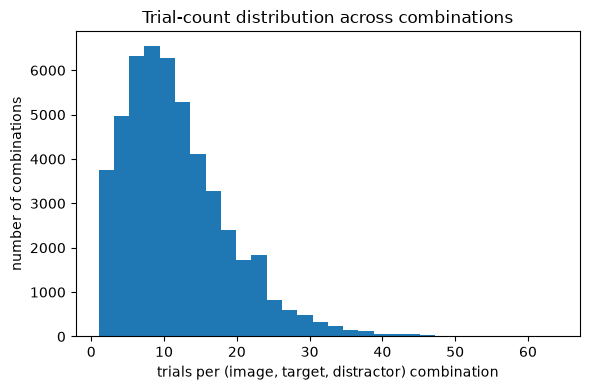

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.hist(trial_counts, bins=30)
plt.xlabel("trials per (image, target, distractor) combination")
plt.ylabel("number of combinations")
plt.title("Trial-count distribution across combinations")
plt.tight_layout()
plt.show()

**Trials distribution across combinations**<br>
Distinct (image, target, distractor) combinations that got tested at least once: 49,492<br>
- min: 1<br>
- median: 10<br>
- max: 64<br>

## 4. Image format: resolution, colour mode, masking

images extracted: 2160


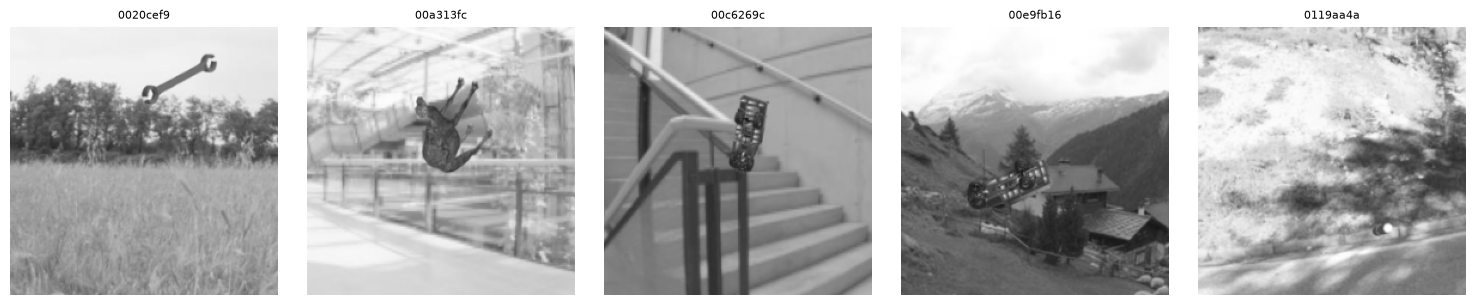

0020cef9: mode/size=(224, 224, 3), greyscale=True
00a313fc: mode/size=(224, 224, 3), greyscale=True
00c6269c: mode/size=(224, 224, 3), greyscale=True
00e9fb16: mode/size=(224, 224, 3), greyscale=True
0119aa4a: mode/size=(224, 224, 3), greyscale=True


In [9]:
import zipfile
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# Same directory is used by notebook 03. Extract every image; display only five.
IMG_DIR = os.path.join(CACHE_DIR, "image_dicarlo_objectome_public")
os.makedirs(IMG_DIR, exist_ok=True)
with zipfile.ZipFile(paths["stimuli_zip"]) as zf:
    png_names = sorted(n for n in zf.namelist() if n.endswith(".png"))
    expected = set(stim_df["filename"].astype(str))
    assert len(png_names) == len(expected) == 2160
    assert set(png_names) == expected
    assert all(os.path.basename(n) == n for n in png_names)
    for name in png_names:
        zf.extract(name, IMG_DIR)
sample_names = png_names[:5]
print("images extracted:", len(png_names))

fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for ax, n in zip(axes, sample_names):
    im = Image.open(os.path.join(IMG_DIR, n))
    ax.imshow(im, cmap="gray")
    ax.set_title(n[:8], fontsize=8)
    ax.axis("off")
plt.tight_layout()
plt.show()

# Greyscale check (R==G==B) 
for n in sample_names:
    a = np.array(Image.open(os.path.join(IMG_DIR, n)))
    is_grey = np.array_equal(a[..., 0], a[..., 1]) and np.array_equal(a[..., 1], a[..., 2])
    print(f"{n[:8]}: mode/size={a.shape}, greyscale={is_grey}")


## Summary

**Public/private status:**
- `dicarlo.Rajalingham2018.public` = 2160 images, 24 categories x 90 images. Every image already has trial data (585,511 trials total, 137-723 trials per image).
- The classic objectome corpus is 2400 images; `2400 - 2160 = 240 = 24 x 10`, matching exactly the "240 images with the most trials" that Brain-Score's paper says it scored on.
- **Conclusion: with public access only, there is no image without human trial data inside what can be downloaded.** All 2160 public images are "tested" and have human trial data.

**Trial-level data, not aggregated:** the assembly is a flat `(presentation,)` array - one row per individual 2AFC trial, with `image_id`, `sample_obj` (target, ==`truth` always), `dist_obj` (distractor), `choice` (what was picked), `WorkerID` (subject), `AssignmentID`.

**Data quality note:** 2 out of 585,511 trials (0.0003%) have a `choice` that matches neither the target nor the distractor shown - excluded in notebook 03.
**Images:** the five checked examples are 224x224 RGB-encoded PNGs that are genuinely greyscale (R=G=B). Natural-scene backgrounds with a rendered object composited in (see figures above).
**Subjects:** `WorkerID` (1391 unique); `AssignmentID` (8185 unique) identifies a single sitting/session.

All 2,160 stimulus images are extracted for notebook 03.